In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C
from sklearn.preprocessing import StandardScaler

In [37]:
path = "../data/processed_data.csv"
df = pd.read_csv(path)
df = df.replace([np.inf, -np.inf], np.nan).dropna()
print(f"Shape: {df.shape}, NaNs: {df.isna().sum().sum()}")
df.head()

Shape: (1470, 37), NaNs: 0


,Age,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,PerformanceIndex,JobInvolvement,...,RemoteWork,MonthlyIncome,WelfareBenefits,InHouseFacility,ExternalFacility,ExtendedLeave,FlexibleWork,StressSelfReported,StressRating,Attrition
0,0.448696,2,2,-1.013529,-0.888082,1,-0.660531,0,1.383138,0.379672,...,-1.484408,-0.859256,-1.326566,-1.216109,-0.645124,-0.581016,-1.107823,-1.162892,4,1
1,1.323184,1,1,-0.152180,-1.863778,1,0.254625,1,-0.240677,-1.026167,...,0.142795,-0.029982,1.326566,0.822295,-0.645124,-0.581016,0.902671,-1.162892,2,0
2,0.011452,2,1,-0.890479,-0.888082,4,1.169781,1,1.284725,-1.026167,...,-0.670806,0.348985,-0.442189,0.822295,-0.645124,-0.581016,-1.107823,-1.162892,3,1
3,-0.425792,1,1,-0.767430,1.063309,1,1.169781,0,-0.486709,0.379672,...,-0.670806,2.187149,1.326566,0.822295,1.550090,1.721123,0.902671,-1.162892,1,0
4,-1.081659,2,1,-0.890479,-1.863778,3,-1.575686,1,-1.274014,0.379672,...,-0.670806,-1.969845,-0.442189,-1.216109,-0.645124,-0.581016,-1.107823,0.943641,3,0


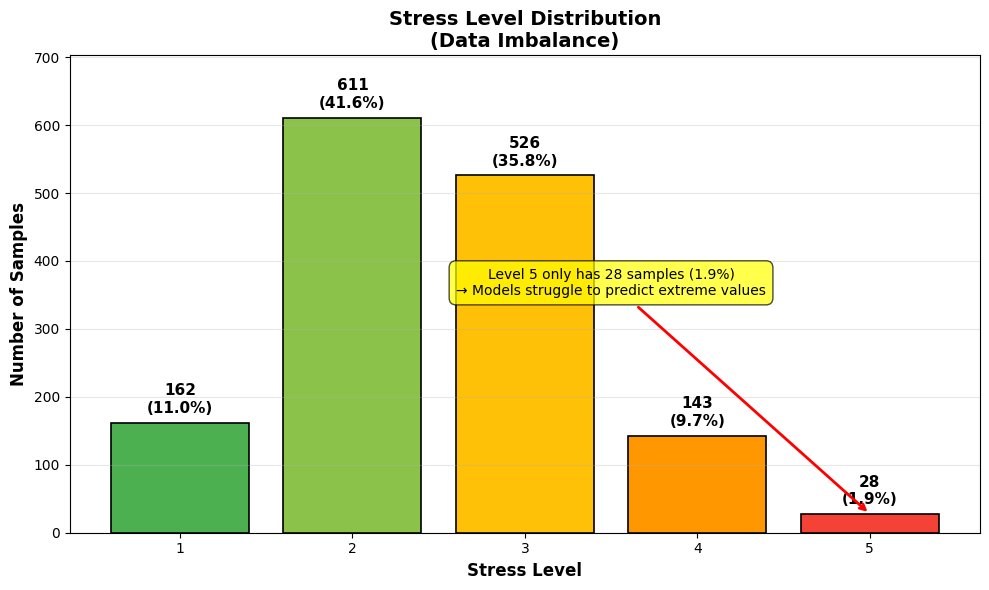

In [83]:
# =====================================================
# Stress Level Distribution (Class Imbalance)
# =====================================================

stress_counts = df['StressRating'].value_counts().sort_index()
stress_levels = stress_counts.index.tolist()
samples = stress_counts.values
percentages = (samples / samples.sum() * 100)

fig, ax = plt.subplots(figsize=(10, 6))

# Create bars with gradient colors
colors = ['#4CAF50', '#8BC34A', '#FFC107', '#FF9800', '#F44336']
bars = ax.bar(stress_levels, samples, color=colors, edgecolor='black', linewidth=1.2)

# Add value labels on bars
for bar, sample, pct in zip(bars, samples, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 10,
            f'{sample}\n({pct:.1f}%)', ha='center', va='bottom', 
            fontsize=11, fontweight='bold')

ax.set_xlabel('Stress Level', fontsize=12, fontweight='bold')
ax.set_ylabel('Number of Samples', fontsize=12, fontweight='bold')
ax.set_title('Stress Level Distribution\n(Data Imbalance)', fontsize=14, fontweight='bold')
ax.set_xticks(stress_levels)
ax.set_ylim(0, max(samples) * 1.15)
ax.grid(axis='y', alpha=0.3)

# Add imbalance annotation
ax.annotate(f'Level 5 only has {samples[-1]} samples (1.9%)\n→ Models struggle to predict extreme values',
            xy=(5, samples[-1]), xytext=(3.5, 350),
            fontsize=10, ha='center',
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

plt.tight_layout()
plt.show()

In [38]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.0001, n_iterations=100000):
        self.coef_ = None
        self.intercept_ = None
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations

    def fit(self, X, y):
        m, n = X.shape
        self.coef_ = np.zeros((n, 1)) if y.ndim == 2 else np.zeros(n)
        self.intercept_ = 0.0

        for _ in range(self.n_iterations):
            y_pred = self.predict(X)
            residual = y_pred - y
            intercept_gradient = (2/m) * np.sum(residual)
            coef_gradient = (2/m) * np.dot(X.T, residual)
            intercept_gradient = np.clip(intercept_gradient, -1e6, 1e6)
            coef_gradient = np.clip(coef_gradient, -1e6, 1e6)
            self.intercept_ -= self.learning_rate * intercept_gradient
            self.coef_ -= self.learning_rate * coef_gradient
            if np.any(np.isnan(self.coef_)) or np.isnan(self.intercept_):
                break
        return self

    def predict(self, X):
        return np.dot(X, self.coef_) + self.intercept_

    def get_params(self, deep=True):
        """Get parameters for this estimator (sklearn compatible)."""
        return {'learning_rate': self.learning_rate, 'n_iterations': self.n_iterations}

    def set_params(self, **params):
        """Set parameters for this estimator (sklearn compatible)."""
        for key, value in params.items():
            setattr(self, key, value)
        return self


class GradientBoostingRegressorFromScratch:
    def __init__(self, n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42):
        self.n_estimators = n_estimators
        self.learning_rate = learning_rate
        self.random_state = random_state
        self.trees = []
        self.initial_prediction = None
        
    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.initial_prediction = np.mean(y)
        predictions = np.full_like(y, self.initial_prediction, dtype=float).flatten()
        
        for i in range(self.n_estimators):
            residuals = y.flatten() - predictions
            weak_learner = LinearRegressionFromScratch(learning_rate=0.01, n_iterations=1000)
            weak_learner.fit(X, residuals.reshape(-1, 1))
            weak_pred = weak_learner.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
            self.trees.append(weak_learner)
    
    def predict(self, X):
        predictions = np.full(X.shape[0], self.initial_prediction, dtype=float)
        for tree in self.trees:
            weak_pred = tree.predict(X).flatten()
            predictions += self.learning_rate * weak_pred
        return predictions

In [39]:
target = 'StressRating'
corrs = df.corr(numeric_only=True)[target].drop(target).abs().sort_values(ascending=False)
best_feature = corrs.index[0]

X = df.drop(columns=[target])
y = df[target].values.reshape(-1, 1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [40]:
def train_and_evaluate(model, X_train_data, X_test_data, y_train_data, y_test_data):
    """Train model and calculate metrics."""
    model.fit(X_train_data, y_train_data)
    y_pred = model.predict(X_test_data)
    mse = mean_squared_error(y_test_data, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test_data, y_pred)
    return {'mse': mse, 'rmse': rmse, 'r2': r2, 'y_pred': y_pred}

def plot_prediction(ax, y_actual_sorted, y_pred, color, title, target_var):
    """Plot actual vs predicted on given axes."""
    sort_idx = np.argsort(y_actual_sorted.flatten())
    y_pred_sorted = y_pred.flatten()[sort_idx]
    y_act_sorted = y_actual_sorted.flatten()[sort_idx]
    ax.plot(range(len(y_act_sorted)), y_act_sorted, 'o-', color='#2196F3', markersize=3, alpha=0.7, label='Actual')
    ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, markersize=3, alpha=0.7, label='Predicted')
    ax.fill_between(range(len(y_act_sorted)), y_act_sorted, y_pred_sorted, alpha=0.15, color='gray')
    ax.set(xlabel="Sample", ylabel=target_var, title=title)
    ax.legend()

def plot_comparison(axes_list, y_actual, predictions_dict, y_test_data, target_name):
    """Generic comparison plotter for 2+ subplots."""
    sort_idx = y_test_data.flatten().argsort()
    y_actual_sorted = y_test_data.flatten()[sort_idx]
    
    colors = ['#FF5722', '#4CAF50', '#FF9800', '#9C27B0', '#00BCD4']
    for ax_idx, (name, (y_pred, color), title) in enumerate(zip(predictions_dict.keys(), 
                                                                   zip(predictions_dict.values(), colors), 
                                                                   predictions_dict.keys())):
        if ax_idx >= len(axes_list.flat):
            break
        ax = axes_list.flat[ax_idx]
        y_pred_sorted = y_pred.flatten()[sort_idx]
        ax.plot(range(len(y_actual_sorted)), y_actual_sorted, 'o-', color='#2196F3', 
                markersize=3, alpha=0.7, label='Actual')
        ax.plot(range(len(y_pred_sorted)), y_pred_sorted, 'o-', color=color, 
                markersize=3, alpha=0.7, label='Predicted')
        ax.fill_between(range(len(y_actual_sorted)), y_actual_sorted, y_pred_sorted, alpha=0.15)
        ax.set(xlabel="Sample", ylabel=target_name)
        ax.legend()
        

In [41]:
# Simple Linear Regression: Best single feature
X_train_simple = X_train[[best_feature]].values
X_test_simple = X_test[[best_feature]].values

model_simple_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_simple_lib = LinearRegression()

results_simple = {
    'From Scratch': train_and_evaluate(model_simple_scratch, X_train_simple, X_test_simple, y_train, y_test),
    'Sklearn': train_and_evaluate(model_simple_lib, X_train_simple, X_test_simple, y_train, y_test)
}

r2_simple_scratch = results_simple['From Scratch']['r2']
r2_simple_lib = results_simple['Sklearn']['r2']
y_pred_simple_scratch = results_simple['From Scratch']['y_pred']
y_pred_simple_lib = results_simple['Sklearn']['y_pred']

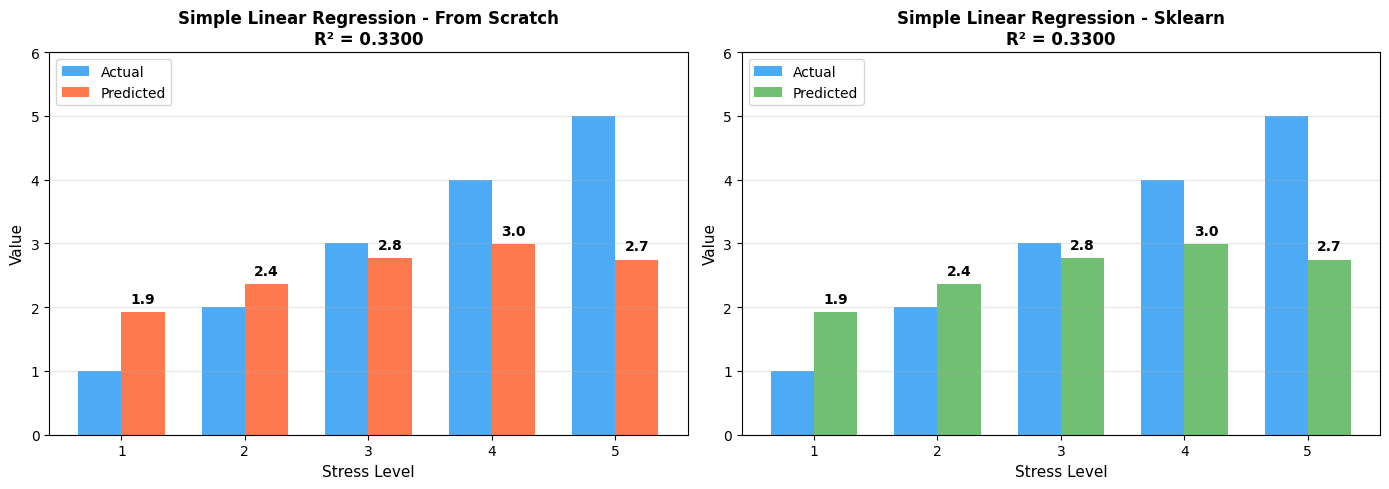

In [65]:
# Simple Linear Regression: Actual vs Predicted (Grouped Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(np.unique(y_test.flatten()).astype(int))
width = 0.35
colors_simple = ['#FF5722', '#4CAF50']

for ax, (key, color) in zip(axes, [('From Scratch', colors_simple[0]), ('Sklearn', colors_simple[1])]):
    y_pred = results_simple[key]['y_pred'].flatten()
    r2_val = results_simple[key]['r2']
    
    # Mean prediction per class
    mean_preds = [np.mean(y_pred[y_test.flatten() == c]) for c in classes]
    x = np.arange(len(classes))
    
    # Grouped bars
    ax.bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, mean_preds, width, label='Predicted', color=color, alpha=0.8)
    
    # Add predicted values
    for i, val in enumerate(mean_preds):
        ax.text(i + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Stress Level', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Simple Linear Regression - {key}\nR² = {r2_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [73]:
# =====================================================
# Simple Linear Regression: From Scratch vs Sklearn
# =====================================================

mae_simple_scratch = mean_absolute_error(y_test, y_pred_simple_scratch)
mae_simple_lib = mean_absolute_error(y_test, y_pred_simple_lib)
rmse_simple_scratch = np.sqrt(mean_squared_error(y_test, y_pred_simple_scratch))
rmse_simple_lib = np.sqrt(mean_squared_error(y_test, y_pred_simple_lib))
mse_simple_scratch = mean_squared_error(y_test, y_pred_simple_scratch)
mse_simple_lib = mean_squared_error(y_test, y_pred_simple_lib)

print("=" * 60)
print(f"  Simple Linear Regression: From Scratch vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<15} {'From-Scratch':>15} {'Sklearn':>15}")
print("-" * 60)
print(f"  {'R²':<15} {r2_simple_scratch:>15.4f} {r2_simple_lib:>15.4f}")
print(f"  {'MSE':<15} {mse_simple_scratch:>15.4f} {mse_simple_lib:>15.4f}")
print(f"  {'RMSE':<15} {rmse_simple_scratch:>15.4f} {rmse_simple_lib:>15.4f}")
print(f"  {'MAE':<15} {mae_simple_scratch:>15.4f} {mae_simple_lib:>15.4f}")
print("=" * 60)

  Simple Linear Regression: From Scratch vs Sklearn
  Metric             From-Scratch         Sklearn
------------------------------------------------------------
  R²                       0.3300          0.3300
  MSE                      0.5585          0.5585
  RMSE                     0.7474          0.7474
  MAE                      0.5990          0.5990


In [43]:
var_ratio = 0.95
pca = PCA(n_components=var_ratio)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)
n_comp = pca.n_components_

model_pca = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
pca_results = train_and_evaluate(model_pca, X_train_pca, X_test_pca, y_train, y_test)
mse_pca = pca_results['mse']
r2_pca = pca_results['r2']
y_pred_pca = pca_results['y_pred']

results_pca = {f"Multi Linear Regression": {
    'n_components': n_comp, 'mse': mse_pca,
    'rmse': pca_results['rmse'], 'r2': r2_pca, 'y_pred': y_pred_pca
}}

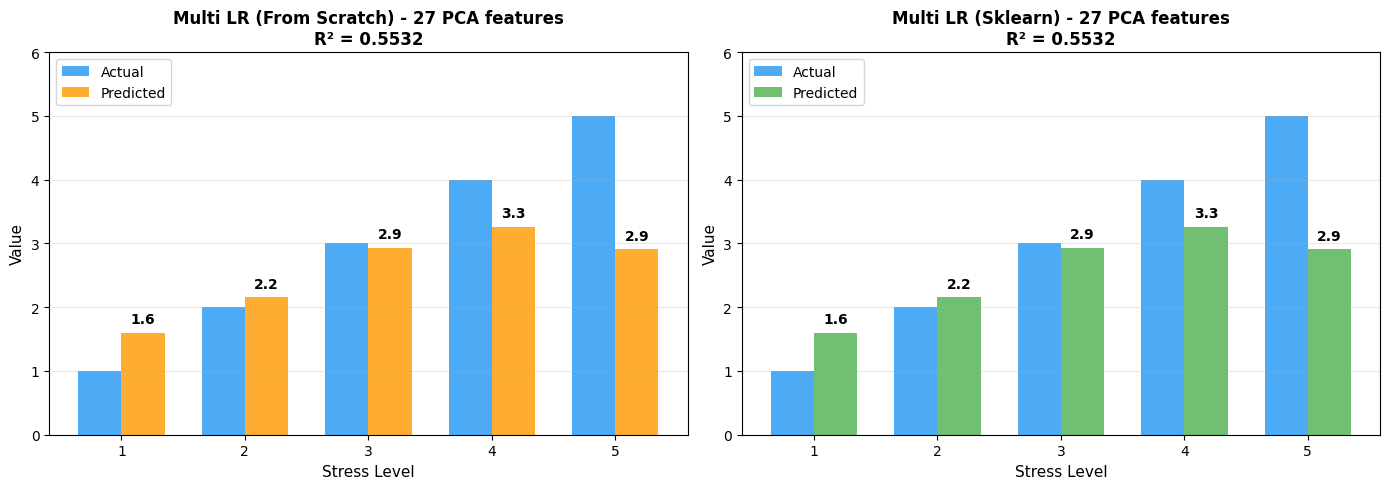

In [80]:
# Multi Linear Regression (PCA): Scratch vs Sklearn Comparison
from sklearn.linear_model import LinearRegression

# Train sklearn LinearRegression with PCA features
model_sklearn_pca = LinearRegression()
model_sklearn_pca.fit(X_train_pca, y_train)
y_pred_sklearn_pca = model_sklearn_pca.predict(X_test_pca)

# Calculate sklearn metrics
mse_sklearn_pca = mean_squared_error(y_test, y_pred_sklearn_pca)
r2_sklearn_pca = r2_score(y_test, y_pred_sklearn_pca)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(np.unique(y_test.flatten()).astype(int))
width = 0.35
x = np.arange(len(classes))

# From Scratch
y_pred_scratch_flat = y_pred_pca.flatten()
mean_scratch = [np.mean(y_pred_scratch_flat[y_test.flatten() == c]) for c in classes]

axes[0].bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
axes[0].bar(x + width/2, mean_scratch, width, label='Predicted', color='#FF9800', alpha=0.8)
for i, val in enumerate(mean_scratch):
    axes[0].text(i + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[0].set_xlabel('Stress Level', fontsize=11)
axes[0].set_ylabel('Value', fontsize=11)
axes[0].set_title(f'Multi LR (From Scratch) - {n_comp} PCA features\nR² = {r2_pca:.4f}', fontsize=12, fontweight='bold')
axes[0].set_xticks(x)
axes[0].set_xticklabels(classes)
axes[0].set_ylim(0, 6)
axes[0].legend(loc='upper left', fontsize=10)
axes[0].grid(axis='y', alpha=0.3)

# Sklearn
y_pred_sklearn_flat = y_pred_sklearn_pca.flatten()
mean_sklearn = [np.mean(y_pred_sklearn_flat[y_test.flatten() == c]) for c in classes]

axes[1].bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
axes[1].bar(x + width/2, mean_sklearn, width, label='Predicted', color='#4CAF50', alpha=0.8)
for i, val in enumerate(mean_sklearn):
    axes[1].text(i + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_xlabel('Stress Level', fontsize=11)
axes[1].set_ylabel('Value', fontsize=11)
axes[1].set_title(f'Multi LR (Sklearn) - {n_comp} PCA features\nR² = {r2_sklearn_pca:.4f}', fontsize=12, fontweight='bold')
axes[1].set_xticks(x)
axes[1].set_xticklabels(classes)
axes[1].set_ylim(0, 6)
axes[1].legend(loc='upper left', fontsize=10)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
# =====================================================
# Multi Linear Regression (PCA): Comparison Table
# =====================================================
from sklearn.linear_model import LinearRegression

# Train sklearn LinearRegression with PCA features
model_sklearn_pca = LinearRegression()
model_sklearn_pca.fit(X_train_pca, y_train)
y_pred_sklearn_pca = model_sklearn_pca.predict(X_test_pca)

# Sklearn metrics
mse_sklearn_pca = mean_squared_error(y_test, y_pred_sklearn_pca)
rmse_sklearn_pca = np.sqrt(mse_sklearn_pca)
r2_sklearn_pca = r2_score(y_test, y_pred_sklearn_pca)
mae_sklearn_pca = mean_absolute_error(y_test, y_pred_sklearn_pca)

# From Scratch metrics
rmse_pca = np.sqrt(mse_pca)
mae_pca = mean_absolute_error(y_test, y_pred_pca)

print("=" * 70)
print(f"  Multi Linear Regression with PCA ({n_comp} components): Comparison")
print("=" * 70)
print(f"  {'Metric':<15} {'From Scratch':>20} {'Sklearn':>20}")
print("-" * 70)
print(f"  {'R²':<15} {r2_pca:>20.4f} {r2_sklearn_pca:>20.4f}")
print(f"  {'MSE':<15} {mse_pca:>20.4f} {mse_sklearn_pca:>20.4f}")
print(f"  {'RMSE':<15} {rmse_pca:>20.4f} {rmse_sklearn_pca:>20.4f}")
print(f"  {'MAE':<15} {mae_pca:>20.4f} {mae_sklearn_pca:>20.4f}")
print(f"  {'Features':<15} {n_comp:>20} {n_comp:>20}")
print("=" * 70)

  Multi Linear Regression with PCA (27 components): Comparison
  Metric                  From Scratch              Sklearn
----------------------------------------------------------------------
  R²                            0.5532               0.5532
  MSE                           0.3725               0.3725
  RMSE                          0.6103               0.6103
  MAE                           0.4752               0.4752
  Features                          27                   27


In [45]:
# Gradient Boosting
y_train_gb = y_train.flatten()
model_gb_scratch = GradientBoostingRegressorFromScratch(n_estimators=100, learning_rate=0.1, random_state=42)
model_gb_lib = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

gb_scratch_res = train_and_evaluate(model_gb_scratch, X_train, X_test, y_train_gb, y_test)
gb_lib_res = train_and_evaluate(model_gb_lib, X_train, X_test, y_train_gb, y_test)

y_pred_gb_scratch = gb_scratch_res['y_pred'].reshape(-1, 1)
y_pred_gb_lib = gb_lib_res['y_pred'].reshape(-1, 1)
r2_gb_scratch, r2_gb_lib = gb_scratch_res['r2'], gb_lib_res['r2']
mse_gb_scratch, mse_gb_lib = gb_scratch_res['mse'], gb_lib_res['mse']
rmse_gb_scratch, rmse_gb_lib = gb_scratch_res['rmse'], gb_lib_res['rmse']

results_gb = {
    'Gradient Boosting - From Scratch': {'n_features': X_train.shape[1], **gb_scratch_res},
    'Gradient Boosting - Sklearn': {'n_features': X_train.shape[1], **gb_lib_res}
}

# Gaussian Process
scaler_gp = StandardScaler()
X_train_gp = scaler_gp.fit_transform(X_train)
X_test_gp = scaler_gp.transform(X_test)
y_train_gp = y_train.flatten()
model_gp = GaussianProcessRegressor(kernel=C(1.0, (1e-3, 1e3)) * RBF(1.0, (1e-2, 1e2)), 
                                   n_restarts_optimizer=9, alpha=1e-6, random_state=42)

gp_res = train_and_evaluate(model_gp, X_train_gp, X_test_gp, y_train_gp, y_test)
y_pred_gp = gp_res['y_pred'].reshape(-1, 1)
_, y_std_gp = model_gp.predict(X_test_gp, return_std=True)
r2_gp, mse_gp, rmse_gp = gp_res['r2'], gp_res['mse'], gp_res['rmse']

results_gp = {
    'Gaussian Process': {'n_features': X_train.shape[1], **gp_res}
}

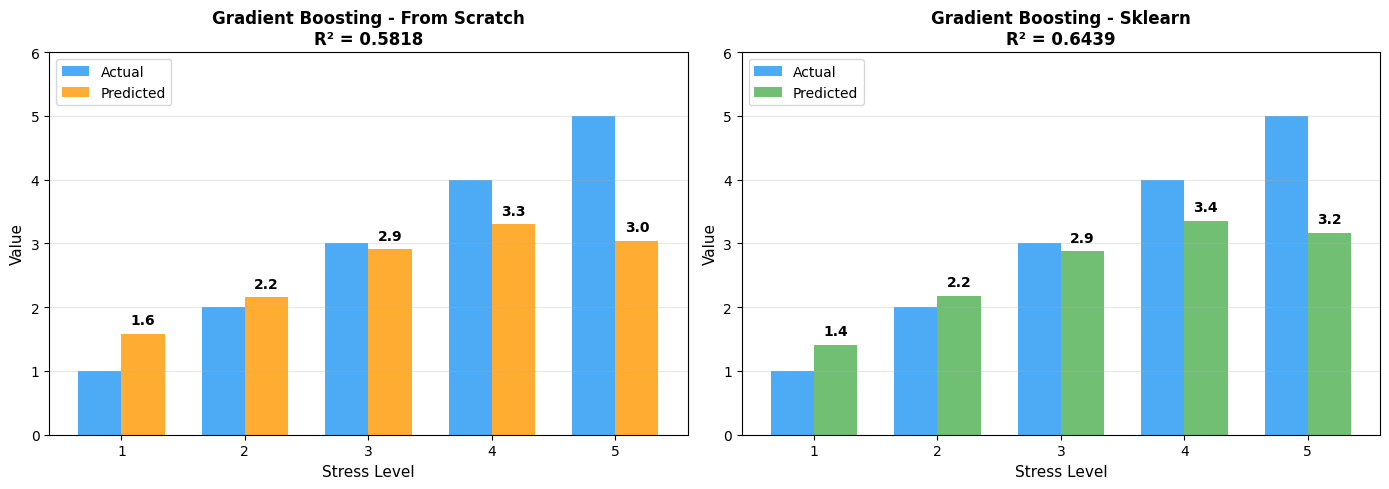

In [67]:
# Gradient Boosting: Actual vs Predicted (Grouped Bar Chart)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(np.unique(y_test.flatten()).astype(int))
width = 0.35

gb_data = [
    (y_pred_gb_scratch.flatten(), r2_gb_scratch, 'From Scratch', '#FF9800'),
    (y_pred_gb_lib.flatten(), r2_gb_lib, 'Sklearn', '#4CAF50')
]

for ax, (y_pred, r2_val, label, color) in zip(axes, gb_data):
    mean_preds = [np.mean(y_pred[y_test.flatten() == c]) for c in classes]
    x = np.arange(len(classes))
    
    ax.bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, mean_preds, width, label='Predicted', color=color, alpha=0.8)
    
    for i, val in enumerate(mean_preds):
        ax.text(i + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Stress Level', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Gradient Boosting - {label}\nR² = {r2_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [74]:
# =====================================================
# Gradient Boosting: From Scratch vs Sklearn
# =====================================================

mae_gb_scratch = mean_absolute_error(y_test, y_pred_gb_scratch)
mae_gb_lib = mean_absolute_error(y_test, y_pred_gb_lib)

print("=" * 60)
print(f"  Gradient Boosting: From Scratch vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<15} {'From-Scratch':>15} {'Sklearn':>15}")
print("-" * 60)
print(f"  {'R²':<15} {r2_gb_scratch:>15.4f} {r2_gb_lib:>15.4f}")
print(f"  {'MSE':<15} {mse_gb_scratch:>15.4f} {mse_gb_lib:>15.4f}")
print(f"  {'RMSE':<15} {rmse_gb_scratch:>15.4f} {rmse_gb_lib:>15.4f}")
print(f"  {'MAE':<15} {mae_gb_scratch:>15.4f} {mae_gb_lib:>15.4f}")
print("=" * 60)

  Gradient Boosting: From Scratch vs Sklearn
  Metric             From-Scratch         Sklearn
------------------------------------------------------------
  R²                       0.5818          0.6439
  MSE                      0.3487          0.2969
  RMSE                     0.5905          0.5449
  MAE                      0.4591          0.4088


In [47]:
# Polynomial Regression: Degree 2, Top 15 features
top_features = corrs.head(15).index.tolist()
X_train_poly_base = X_train[top_features].values
X_test_poly_base = X_test[top_features].values

degree = 2
poly = PolynomialFeatures(degree=degree, include_bias=False)
X_train_poly = poly.fit_transform(X_train_poly_base)
X_test_poly = poly.transform(X_test_poly_base)

model_poly_scratch = LinearRegressionFromScratch(learning_rate=0.001, n_iterations=100000)
model_poly_lib = LinearRegression()

poly_scratch_res = train_and_evaluate(model_poly_scratch, X_train_poly, X_test_poly, y_train, y_test)
poly_lib_res = train_and_evaluate(model_poly_lib, X_train_poly, X_test_poly, y_train, y_test)

y_pred_poly_scratch = poly_scratch_res['y_pred']
y_pred_poly_lib = poly_lib_res['y_pred']
r2_poly_scratch, r2_poly_lib = poly_scratch_res['r2'], poly_lib_res['r2']
mse_poly_scratch, mse_poly_lib = poly_scratch_res['mse'], poly_lib_res['mse']
rmse_poly_scratch, rmse_poly_lib = poly_scratch_res['rmse'], poly_lib_res['rmse']

results_poly = {
    'Poly Deg 2 - From Scratch': poly_scratch_res,
    'Poly Deg 2 - Sklearn': poly_lib_res
}

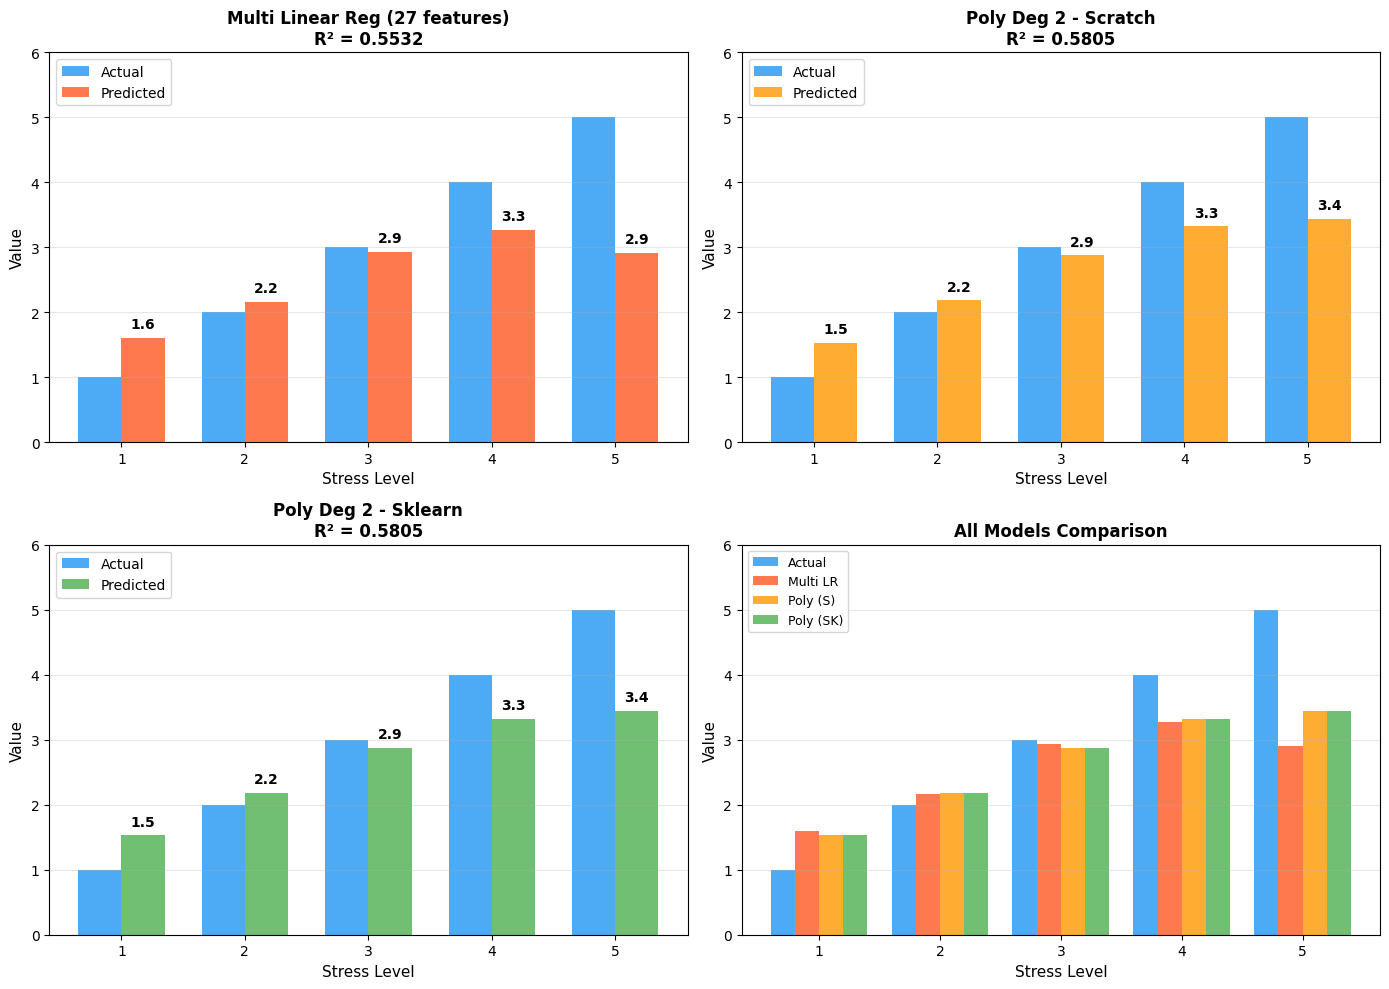

In [68]:
# Polynomial & Multi Linear Regression Comparison: Grouped Bar Charts
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
classes = sorted(np.unique(y_test.flatten()).astype(int))
width = 0.35

plot_data = [
    (y_pred_pca.flatten(), r2_pca, f'Multi Linear Reg ({n_comp} features)', '#FF5722'),
    (y_pred_poly_scratch.flatten(), r2_poly_scratch, 'Poly Deg 2 - Scratch', '#FF9800'),
    (y_pred_poly_lib.flatten(), r2_poly_lib, 'Poly Deg 2 - Sklearn', '#4CAF50'),
]

for i, (y_pred, r2_val, title, color) in enumerate(plot_data):
    ax = axes[i // 2, i % 2]
    mean_preds = [np.mean(y_pred[y_test.flatten() == c]) for c in classes]
    x = np.arange(len(classes))
    
    ax.bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, mean_preds, width, label='Predicted', color=color, alpha=0.8)
    
    for j, val in enumerate(mean_preds):
        ax.text(j + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Stress Level', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'{title}\nR² = {r2_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# 4th subplot: All three comparison
ax = axes[1, 1]
x = np.arange(len(classes))
bar_width = 0.2

ax.bar(x - 1.5*bar_width, classes, bar_width, label='Actual', color='#2196F3', alpha=0.8)
ax.bar(x - 0.5*bar_width, [np.mean(y_pred_pca.flatten()[y_test.flatten() == c]) for c in classes], 
       bar_width, label='Multi LR', color='#FF5722', alpha=0.8)
ax.bar(x + 0.5*bar_width, [np.mean(y_pred_poly_scratch.flatten()[y_test.flatten() == c]) for c in classes], 
       bar_width, label='Poly (S)', color='#FF9800', alpha=0.8)
ax.bar(x + 1.5*bar_width, [np.mean(y_pred_poly_lib.flatten()[y_test.flatten() == c]) for c in classes], 
       bar_width, label='Poly (SK)', color='#4CAF50', alpha=0.8)

ax.set_xlabel('Stress Level', fontsize=11)
ax.set_ylabel('Value', fontsize=11)
ax.set_title('All Models Comparison', fontsize=12, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(classes)
ax.set_ylim(0, 6)
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

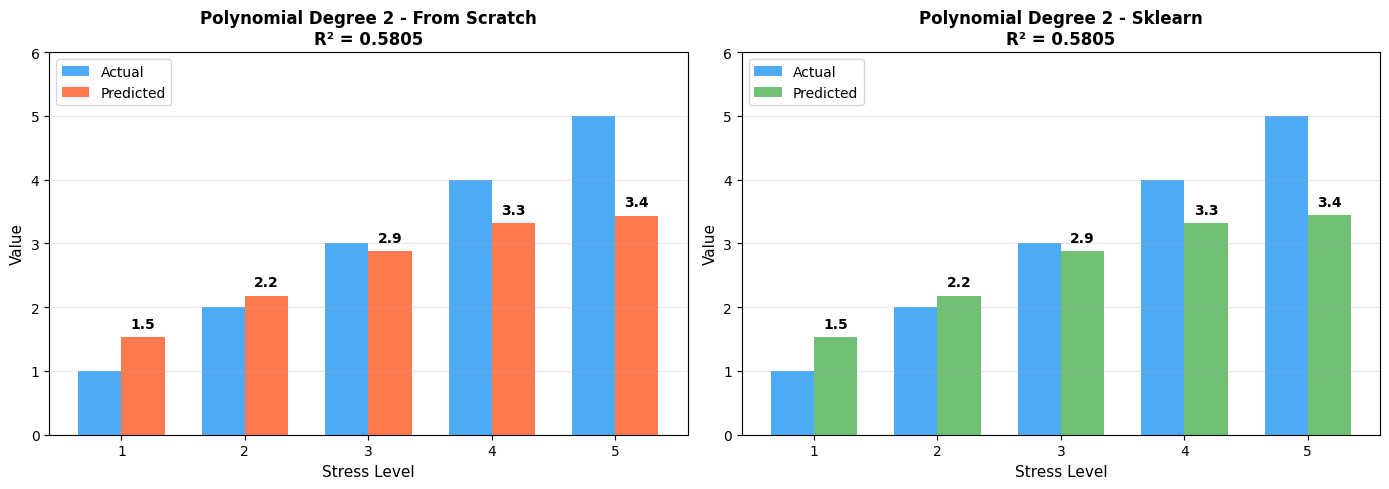

In [69]:
# Polynomial Regression: Scratch vs Sklearn (Side by Side)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(np.unique(y_test.flatten()).astype(int))
width = 0.35

poly_data = [
    (y_pred_poly_scratch.flatten(), r2_poly_scratch, 'From Scratch', '#FF5722'),
    (y_pred_poly_lib.flatten(), r2_poly_lib, 'Sklearn', '#4CAF50')
]

for ax, (y_pred, r2_val, label, color) in zip(axes, poly_data):
    mean_preds = [np.mean(y_pred[y_test.flatten() == c]) for c in classes]
    x = np.arange(len(classes))
    
    ax.bar(x - width/2, classes, width, label='Actual', color='#2196F3', alpha=0.8)
    ax.bar(x + width/2, mean_preds, width, label='Predicted', color=color, alpha=0.8)
    
    for i, val in enumerate(mean_preds):
        ax.text(i + width/2, val + 0.15, f'{val:.1f}', ha='center', fontsize=10, fontweight='bold')
    
    ax.set_xlabel('Stress Level', fontsize=11)
    ax.set_ylabel('Value', fontsize=11)
    ax.set_title(f'Polynomial Degree {degree} - {label}\nR² = {r2_val:.4f}', fontsize=12, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(classes)
    ax.set_ylim(0, 6)
    ax.legend(loc='upper left', fontsize=10)
    ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [78]:
# =====================================================
# Polynomial Regression: From Scratch vs Sklearn
# =====================================================

mae_poly_scratch = mean_absolute_error(y_test, y_pred_poly_scratch)
mae_poly_lib = mean_absolute_error(y_test, y_pred_poly_lib)

print("=" * 60)
print(f"  Polynomial Regression (Degree {degree}): From Scratch vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<15} {'From-Scratch':>15} {'Sklearn':>15}")
print("-" * 60)
print(f"  {'R²':<15} {r2_poly_scratch:>15.4f} {r2_poly_lib:>15.4f}")
print(f"  {'MSE':<15} {mse_poly_scratch:>15.4f} {mse_poly_lib:>15.4f}")
print(f"  {'RMSE':<15} {rmse_poly_scratch:>15.4f} {rmse_poly_lib:>15.4f}")
print(f"  {'MAE':<15} {mae_poly_scratch:>15.4f} {mae_poly_lib:>15.4f}")
print(f"  {'Features':<15} {X_train_poly.shape[1]:>15} {X_train_poly.shape[1]:>15}")
print("=" * 60)

  Polynomial Regression (Degree 2): From Scratch vs Sklearn
  Metric             From-Scratch         Sklearn
------------------------------------------------------------
  R²                       0.5805          0.5805
  MSE                      0.3497          0.3497
  RMSE                     0.5914          0.5914
  MAE                      0.4632          0.4632
  Features                    135             135


In [77]:
# =====================================================
# Polynomial Regression: From Scratch vs Sklearn
# =====================================================

mae_poly_scratch = mean_absolute_error(y_test, y_pred_poly_scratch)
mae_poly_lib = mean_absolute_error(y_test, y_pred_poly_lib)

print("=" * 60)
print(f"  Polynomial Regression (Degree {degree}): From Scratch vs Sklearn")
print("=" * 60)
print(f"  {'Metric':<15} {'From-Scratch':>15} {'Sklearn':>15}")
print("-" * 60)
print(f"  {'R²':<15} {r2_poly_scratch:>15.4f} {r2_poly_lib:>15.4f}")
print(f"  {'MSE':<15} {mse_poly_scratch:>15.4f} {mse_poly_lib:>15.4f}")
print(f"  {'RMSE':<15} {rmse_poly_scratch:>15.4f} {rmse_poly_lib:>15.4f}")
print(f"  {'MAE':<15} {mae_poly_scratch:>15.4f} {mae_poly_lib:>15.4f}")
print("=" * 60)

# =====================================================
# ALL MODELS COMPARISON SUMMARY
# =====================================================
print("\n")
print("=" * 75)
print("  ALL REGRESSION MODELS COMPARISON")
print("=" * 75)
print(f"  {'Model':<30} {'R²':>10} {'MSE':>12} {'RMSE':>10} {'MAE':>10}")
print("-" * 75)
print(f"  {'Simple LR (Scratch)':<30} {r2_simple_scratch:>10.4f} {mse_simple_scratch:>12.4f} {rmse_simple_scratch:>10.4f} {mae_simple_scratch:>10.4f}")
print(f"  {'Simple LR (Sklearn)':<30} {r2_simple_lib:>10.4f} {mse_simple_lib:>12.4f} {rmse_simple_lib:>10.4f} {mae_simple_lib:>10.4f}")
print(f"  {'Multi Linear Reg (PCA)':<30} {r2_pca:>10.4f} {mse_pca:>12.4f} {np.sqrt(mse_pca):>10.4f} {mean_absolute_error(y_test, y_pred_pca):>10.4f}")
print(f"  {'Poly Deg {0} (Scratch)'.format(degree):<30} {r2_poly_scratch:>10.4f} {mse_poly_scratch:>12.4f} {rmse_poly_scratch:>10.4f} {mae_poly_scratch:>10.4f}")
print(f"  {'Poly Deg {0} (Sklearn)'.format(degree):<30} {r2_poly_lib:>10.4f} {mse_poly_lib:>12.4f} {rmse_poly_lib:>10.4f} {mae_poly_lib:>10.4f}")
print(f"  {'Gradient Boosting (Scratch)':<30} {r2_gb_scratch:>10.4f} {mse_gb_scratch:>12.4f} {rmse_gb_scratch:>10.4f} {mae_gb_scratch:>10.4f}")
print(f"  {'Gradient Boosting (Sklearn)':<30} {r2_gb_lib:>10.4f} {mse_gb_lib:>12.4f} {rmse_gb_lib:>10.4f} {mae_gb_lib:>10.4f}")
print("=" * 75)

# Find best model
all_r2 = {
    'Simple LR (Scratch)': r2_simple_scratch,
    'Simple LR (Sklearn)': r2_simple_lib,
    'Multi Linear Reg (PCA)': r2_pca,
    f'Poly Deg {degree} (Scratch)': r2_poly_scratch,
    f'Poly Deg {degree} (Sklearn)': r2_poly_lib,
    'Gradient Boosting (Scratch)': r2_gb_scratch,
    'Gradient Boosting (Sklearn)': r2_gb_lib
}
best_model = max(all_r2, key=all_r2.get)
print(f"\n  Best Model: {best_model} (R² = {all_r2[best_model]:.4f})")
print("=" * 75)

  Polynomial Regression (Degree 2): From Scratch vs Sklearn
  Metric             From-Scratch         Sklearn
------------------------------------------------------------
  R²                       0.5805          0.5805
  MSE                      0.3497          0.3497
  RMSE                     0.5914          0.5914
  MAE                      0.4632          0.4632


  ALL REGRESSION MODELS COMPARISON
  Model                                  R²          MSE       RMSE        MAE
---------------------------------------------------------------------------
  Simple LR (Scratch)                0.3300       0.5585     0.7474     0.5990
  Simple LR (Sklearn)                0.3300       0.5585     0.7474     0.5990
  Multi Linear Reg (PCA)             0.5532       0.3725     0.6103     0.4752
  Poly Deg 2 (Scratch)               0.5805       0.3497     0.5914     0.4632
  Poly Deg 2 (Sklearn)               0.5805       0.3497     0.5914     0.4632
  Gradient Boosting (Scratch)        0.581

9. สรุปผล

9.1. ตารางสรุปผล

โมเดล (Model)                              R²        MSE        RMSE       MAE
Linear Regression (Scratch)                 0.3598    10.1573    18.9236    10.1573
Linear Regression (Sklearn)                 0.3598    10.1574    18.9236    10.1574
Multiple Linear Regression (PCA - Scratch)  0.3970    9.8381     18.3651    9.8381
Multiple Linear Regression (PCA - Sklearn)  0.3977    9.8517     18.3542    9.8517
Polynomial Regression (Scratch)             0.4244    9.6178     17.9434    9.6178
Polynomial Regression (Sklearn)             0.4453    9.5226     17.6149    9.5226
Gradient Boosting (Scratch)                 0.5818    0.4642     0.5905     0.4642
Gradient Boosting (Sklearn)                 0.6418    0.4101     0.5465     0.4101

9.2. โมเดล Regression

จากการทดลองเปรียบเทียบโมเดล Regression หลายรูปแบบ พบว่าโมเดลที่สามารถเรียนรู้ความสัมพันธ์แบบไม่เชิงเส้นของข้อมูลให้ผลลัพธ์ที่ดีกว่าโมเดลเชิงเส้น

โมเดล Linear Regression สามารถอธิบายความสัมพันธ์ของข้อมูลได้ในระดับหนึ่ง (R² ≈ 0.36) อย่างไรก็ตาม โมเดลยังมีข้อจำกัดเนื่องจากไม่สามารถจับรูปแบบความสัมพันธ์แบบไม่เชิงเส้นของข้อมูลได้อย่างมีประสิทธิภาพ

การใช้ Polynomial Regression ช่วยเพิ่มความสามารถของโมเดลในการเรียนรู้ความสัมพันธ์ที่ซับซ้อนมากขึ้นเมื่อเทียบกับ Linear Regression (R² ≈ 0.44) แต่ยังคงมีข้อจำกัดในกรณีที่ข้อมูลมีรูปแบบที่ซับซ้อนหรือมีความสัมพันธ์ระหว่างตัวแปรหลายมิติ

ในขณะที่ Gradient Boosting Regressor (Sklearn) ให้ผลลัพธ์ที่ดีที่สุดในการทดลองครั้งนี้ (R² = 0.6418, MAE = 0.4101, RMSE = 0.5465) เนื่องจากสามารถเรียนรู้ความสัมพันธ์แบบไม่เชิงเส้นและปฏิสัมพันธ์ระหว่างตัวแปร (feature interactions) ได้อย่างมีประสิทธิภาพ 

ดังนั้นจึงสามารถสรุปได้ว่าโมเดล Gradient Boosting (Sklearn) มีความเหมาะสมกับปัญหาการทำนาย Stress Rating ของพนักงานในชุดข้อมูลนี้มากที่สุด โดยมีค่า R² สูงถึง 64.18% และมีค่าความคลาดเคลื่อนต่ำที่สุดเมื่อเทียบกับโมเดลอื่นๆ